In [1]:
#Imports
import numpy as np
import matplotlib.pyplot as plt
import collections
import ROOT as root
import awkward as ak
import uproot
from array import array
import torch
from scipy.spatial import Delaunay
from torch_geometric.data import Data, Dataset
import sys
import os

Welcome to JupyROOT 6.26/16


In [2]:
#This notebook is mostly focused on building a more robust labeling system. Not as good as spine but better than what is currently in the AddInfo function in ClusterToGraph.
#Core idea from the ML group, semantic labels are hit-wise but do not need to be determined hit-wise. 
#Import needed files
DBSCAN_file = np.load('/sdf/data/neutrino/summer25/ktwall/tms_timing/dbscan_clustered/hits_DBSCAN_clustered_epsilon_0.1_2530.npz')
dbscan_hits = DBSCAN_file['first']

merged_hits_file = np.load('/sdf/data/neutrino/summer25/ktwall/tms_timing/multihit/mulithit_detector_sim_lossy_2530.npz')
merged_hits_array = merged_hits_file['first']
n_neutrino_events = merged_hits_file['second']

f = root.TFile.Open("/sdf/data/neutrino/summer25/tanaka/nd-production/run-spill-build/MicroProdN4p1_NDComplex_FHC.spill.full/EDEPSIM_SPILLS/0002000/0002500/MicroProdN4p1_NDComplex_FHC.spill.full.0002543.EDEPSIM_SPILLS.root")
edep_events = f.Get("EDepSimEvents")
# Set the branch address.
event = root.TG4Event()
edep_events.SetBranchAddress("Event",root.AddressOf(event))
print("loaded")

loaded


In [3]:
#whole file statistics will be usefull in making threshold decisions:

#Generate a dictionary for the whole file at the top, more memory efficient 
nns_in_file = np.unique(dbscan_hits[:,0])
dbscan_file_dict = {} #holds the hit info dictionary for a given event. 
for nn in nns_in_file:
    event_merged_hits = merged_hits_array[merged_hits_array[:,0] == nn ]
    hit_numbers = event_merged_hits[:,1]
    edep_events.GetEntry(int(nn))
    event_hit_segments = event.SegmentDetectors['volTMS']
    trackid_dict = {} #stores hit number trackid pair. (hit # : trackid)
    
    for hit_number in hit_numbers:
        hit_segment = event_hit_segments[int(hit_number)]
        contrib_vector = hit_segment.Contrib
        trackid_dict[int(hit_number)] = contrib_vector[0] #just pulling trackid of first contributor to segment 

    pdgid_dict = {} #(trackid : pdgid)
    event_trajectories = event.Trajectories
    for trackid in trackid_dict.values():
        pdgid = event_trajectories[trackid].GetPDGCode()
        pdgid_dict[trackid] = pdgid

    #now create a different dictionary - call it info dict. looks like (hit # : (trackid, pdgid) ). 
    hit_info_dict = {}
    for hit_number in hit_numbers:
        hit_trackid = trackid_dict[hit_number]
        hit_pdgid = pdgid_dict[hit_trackid]
        hit_info_dict[int(hit_number)] = (hit_trackid, hit_pdgid)

    dbscan_file_dict[int(nn)] = hit_info_dict

In [4]:
#I would like to see a mask that categorizes by neutrino event that originated in the tms vs one that didn't. Not sure how useful this will be but could be interesting. 
edep_detsim = f.Get("DetSimPassThru") #grab detsim, should contain the gRooTracker
tracker_tree = edep_detsim.gRooTracker 

edep_true_neutrino_vtx = [] 
vtxs = array('d', [0.0]*5) 
tracker_tree.SetBranchAddress("EvtVtx", vtxs)
neutrino_vtxs_info = {}
for i in range(tracker_tree.GetEntries()):
    tracker_tree.GetEntry(i)
    #don't forget to scale positions (tracker inexplicably uses m)
    x = vtxs[0]*1000
    y = vtxs[1]*1000
    z = vtxs[2]*1000
    in_tms = 0 #default is not in the tms
    if (11185 <= z <= 18535): #check if in z range of tms
        if (-3730 <= x <= 3730): #check if in x range of tms (?)
            if (-2350 <= y <= 2350): #check if in y range of tms (?)
                in_tms = 1
    neutrino_vtxs_info[i] = (vtxs[0]*1000,vtxs[1]*1000,vtxs[2]*1000, in_tms) #x, y, z, in_tms (0 if false, 1 if true)

In [5]:
#a nest loop that gets down to the level of dbscan_cluster_level hits. 
dbscan_cluster_list = []
spills_in_file = np.unique(dbscan_hits[:,-4])
for spill_number in spills_in_file:
    spill_level = dbscan_hits[dbscan_hits[:,-4] == spill_number]
    segments_in_spill = np.unique(spill_level[:,-2])
    for segment_number in segments_in_spill:
        time_segment_level = spill_level[spill_level[:,-2] == segment_number]
        clusters_in_segment = np.unique(time_segment_level[:,-1])
        for cluster_number in clusters_in_segment:
            dbscan_cluster_level = time_segment_level[time_segment_level[:,-1] == cluster_number]
            rows = []
            for hit in dbscan_cluster_level:
                nn = hit[0]
                hn = hit[1]
                hit_info = (dbscan_file_dict[nn])[hn] #grabbing relevant hit information. 
                hit_trackid, hit_pdgid = hit_info
                in_tms = (neutrino_vtxs_info[int(nn)])[3]
                addition = np.array((hit_trackid, hit_pdgid, in_tms))
                new_row = np.hstack((hit, addition))
                rows.append(new_row)
    
            dbscan_hits_with_info = np.vstack(rows)
            dbscan_cluster_list.append(dbscan_hits_with_info)

In [23]:
chosen_slice = 1
slice_hits = dbscan_cluster_list[chosen_slice]

trackid_separated = []
for nn in np.unique(slice_hits[:,0]):
    nn_sub_array = slice_hits[slice_hits[:,0] == nn]
    for trackid in np.unique(nn_sub_array[:,-3]):
        trackid_sub_array = nn_sub_array[nn_sub_array[:,-3] == trackid]
        trackid_separated.append(trackid_sub_array)

In [24]:
#this statement need to be explicit or it can lead to errors for some reason
basic_tracks = []
basic_showers = []
for trackid_group in trackid_separated:
    if np.shape(trackid_group)[0] > 4:
        basic_tracks.append(trackid_group)
    if np.shape(trackid_group)[0] <= 4:
        basic_showers.append(trackid_group)

#create primary track list!
primary_track_list = []
for track_group in basic_tracks:
    primary_track_list.append( (int(track_group[0][0]), int(track_group[0][-3])) )

In [25]:
advanced_tracks = basic_tracks
advanced_showers = []

#local context
for group in basic_showers:
    nn = group[0][0] #grab neutrino # for group
    trackid = group[0][-3] #grab the trackid for the group
    #now quickly grab the trackids of our primary track groups associated w/this event, for use
    edep_events.GetEntry(int(nn))
    event_trajectories = event.Trajectories #fetch trajectories vector
    group_traj = event_trajectories[int(trackid)] #our root trajectory 
    group_traj_parent = group_traj.GetParentId()
    parent_tuple_reference = (int(nn), int(group_traj_parent))
    added = False
    
    for i, ptref in enumerate(primary_track_list): #i will key which index of the track list to add to. 
        #check first if the parent matches
        if ptref == parent_tuple_reference:
            #print('found a shower w/ a main track parent')
            #print(f'{parent_tuple_reference} and {ptref}')
            advanced_tracks[i] = (np.vstack((basic_tracks[i], group)) )
            added = True
          
        #if not, check if the grandparent matches, to expand tracks even further. 
        if added ==  False:
            group_traj_grandparent = event_trajectories[int(group_traj_parent)].GetParentId()
            grandparent_tuple_reference = (int(nn), int(group_traj_grandparent))
            if ptref == grandparent_tuple_reference:
                advanced_tracks[i] = (np.vstack((basic_tracks[i], group)) )
                added = True
       
        #if not check if the great grandparent matches, expands it even further!! This one may be a bit of a step far. 
        
        if added ==  False:
            group_traj_great_grandparnet = event_trajectories[int(group_traj_grandparent)].GetParentId()
            great_grandparent_tuple_reference = (int(nn), int(group_traj_great_grandparnet))
            if ptref == great_grandparent_tuple_reference:
                advanced_tracks[i] = (np.vstack((basic_tracks[i], group)) )
                added = True
        """   
        if added == False:
            if (np.shape(group)[0] == 1):
                if group[0][6] < 4:
                    diffuse.append(group)
                    added = True
        """  
    
    if added == False:
        advanced_showers.append(group)

In [26]:
to_stack = []
if len(advanced_tracks) > 0:
    advanced_tracks_array = np.vstack(advanced_tracks)
    tracks_labeled = np.column_stack(((advanced_tracks_array[:,4],advanced_tracks_array[:,2],advanced_tracks_array[:,6], np.zeros_like(advanced_tracks_array[:,0]))))
    to_stack.append(tracks_labeled)
if len(advanced_showers) > 0:
    advanced_showers_array = np.vstack(advanced_showers)
    showers_labeled = np.column_stack(((advanced_showers_array[:,4],advanced_showers_array[:,2],advanced_showers_array[:,6], np.ones_like(advanced_showers_array[:,0]))))
    to_stack.append(showers_labeled)
print(len(to_stack))

2


In [27]:
#lets assign labels and concatenate 
slice_labeled = np.vstack(to_stack)

In [28]:
#this little chat gpt tidbit efficiently sweeps for duplicates and keeps ones with label 1 
xz = slice_labeled[:, [0, 1]]
_, unique_indices, inverse = np.unique(xz, axis=0, return_index=True, return_inverse=True)

# Step 2: prepare output list
selected_indices = []

# Step 3: for each group of same (x,z), pick one with label==0 if any
for group_id in range(len(unique_indices)):
    group_indices = np.where(inverse == group_id)[0]
    group = slice_labeled[group_indices]
    
    # Find label==0 hit in group, if any
    label_0_indices = group_indices[slice_labeled[group_indices, 3] == 0]
    if len(label_0_indices) > 0:
        selected_indices.append(label_0_indices[0])  # pick first label==0
    else:
        selected_indices.append(group_indices[0])  # pick first if no label==0

# Step 4: collect filtered hits
filtered_labeled_slice = slice_labeled[selected_indices]

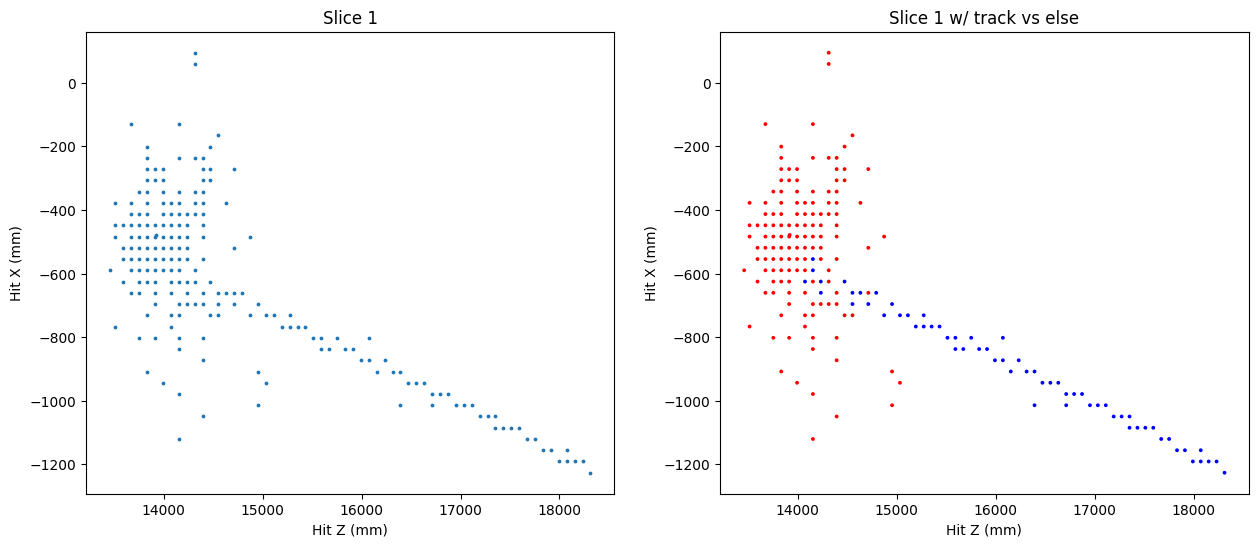

In [29]:
colors = []
for hit in filtered_labeled_slice:
    if hit[-1] == 0:
        colors.append('blue')
    else:
        colors.append('red')
             
if (len(np.unique(filtered_labeled_slice[:-1])) > 1): #check to make sure have two labels, else bad comp. 
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    sc1 = ax1.scatter(filtered_labeled_slice[:,0], filtered_labeled_slice[:,1], s = 3)
    #ax1.set_xlim((11100,19000))
    ax1.set_title(f'Slice {chosen_slice}')
    #ax1.set_ylim((-3650,3650))
    ax1.set_xlabel("Hit Z (mm)")
    ax1.set_ylabel("Hit X (mm)")

    sc2 = ax2.scatter(filtered_labeled_slice[:,0], filtered_labeled_slice[:,1], s = 3, c = colors)
    ax2.set_title(f'Slice {chosen_slice} w/ track vs else')
    #ax2.set_xlim((11100,19000))
    #ax2.set_ylim((-3650,3650))
    ax2.set_xlabel("Hit Z (mm)")
    ax2.set_ylabel("Hit X (mm)")

In [370]:
unique_zs, inverse_z, counts_z = np.unique(filtered_labeled_slice[:,0], return_counts=True, return_inverse = True )
unique_xs, inverse_x, counts_x = np.unique(filtered_labeled_slice[:,1], return_counts=True, return_inverse = True )

In [374]:
"""
isolated_track_hits = []
for i, layer in enumerate(unique_zs):
    zs_sub = filtered_labeled_slice[filtered_labeled_slice[:,0] == unique_zs[i]]
    if len(np.unique(zs_sub[:,-1])) > 1: #look for zs w/ mulitple labels
        z_label_counts = np.unique(zs_sub[:,-1], return_counts=True)[1]
        if (z_label_counts[1] / z_label_counts[0]) >= 3:
            #print(label_counts)
            isolated_candidates = zs_sub[zs_sub[:,-1] == 0]
            isolated_x_layers = np.unique(isolated_candidates[:,1])
            for x_layer in isolated_x_layers:
                x_sub = filtered_labeled_slice[filtered_labeled_slice[:,1] == x_layer]
                #print(isolated_candidates[0][0])
                #print(x_sub)
                proximity_mask = abs(x_sub[:,0] - isolated_candidates[0][0]) < 500
                #print(proximity_mask)
                #print(x_sub[proximity_mask])
                #proximity_masked_xs = x_sub[proximity_mask]
                x_label_counts = np.unique(x_sub[:,-1], return_counts=True)[1]
                if (np.shape(x_label_counts)[0]) > 1: #check to make sure that there are at least some shower points
                    if (x_label_counts[1] / x_label_counts[0]) >= 2:
                        print(z_label_counts)
                        print(x_label_counts)
                        print(isolated_candidates[isolated_candidates[:,1] == x_layer])
                        isolated_track_hits.append(isolated_candidates[isolated_candidates[:,1] == x_layer])
                    """      
"""
if len(isolated_track_hits) > 0:
    isolated_tracks_array = np.vstack(isolated_track_hits)
    print(isolated_tracks_array)

plt.scatter(filtered_labeled_slice[:,0], filtered_labeled_slice[:,1], s=3, c = colors)
if len(isolated_track_hits) > 0:
    plt.scatter(isolated_tracks_array[:,0], isolated_tracks_array[:,1], c= 'black', s =3)
#plt.xlim((11100,19000))
#plt.ylim((-3650,3650))
"""

"\nif len(isolated_track_hits) > 0:\n    isolated_tracks_array = np.vstack(isolated_track_hits)\n    print(isolated_tracks_array)\n\nplt.scatter(filtered_labeled_slice[:,0], filtered_labeled_slice[:,1], s=3, c = colors)\nif len(isolated_track_hits) > 0:\n    plt.scatter(isolated_tracks_array[:,0], isolated_tracks_array[:,1], c= 'black', s =3)\n#plt.xlim((11100,19000))\n#plt.ylim((-3650,3650))\n"

In [14]:
np.full((4,1),5)

array([[5, 5, 5, 5]])

In [17]:
np.full((4,1),6)
np.column_stack((np.full((4,1),6), np.full((4,1),5)))

array([[6, 5],
       [6, 5],
       [6, 5],
       [6, 5]])

In [20]:
np.full((1,4),5)

array([[5, 5, 5, 5]])